# Regresión — Predicción del Puntaje Global Saber 11 (Córdoba)

**Objetivo:** Predecir el puntaje global Saber 11 a partir de variables de contexto familiar y escolar disponibles antes de la prueba.

**Flujo:**
1. Carga y exploración de variables
2. Preprocesamiento y estandarización
3. Lasso para selección de variables
4. Redes neuronales — comparación de arquitecturas
5. Tabla de métricas completa

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, explained_variance_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import mlflow, mlflow.keras

tf.random.set_seed(42)
np.random.seed(42)

mlflow.set_tracking_uri('file:./mlruns')
mlflow.set_experiment('Regresion_PuntajeGlobal')

print('TF:', tf.__version__)

TF: 2.20.0


## 1. Carga de datos

In [17]:
df = pd.read_csv('../Resultados_ICFES_Cordoba_clean.csv')

# Solo filas con punt_global disponible
df_reg = df.dropna(subset=['punt_global']).copy()

print(f'Filas con punt_global: {df_reg.shape[0]:,}  |  Columnas: {df_reg.shape[1]}')
print()
print(df_reg['punt_global'].describe().round(2))

Filas con punt_global: 118,523  |  Columnas: 51

count    118523.00
mean        240.98
std          46.01
min           0.00
25%         207.00
50%         235.00
75%         270.00
max         471.00
Name: punt_global, dtype: float64


## 2. Exploración de variables

Antes de modelar exploramos cómo cada variable se relaciona con `punt_global`. Esto da intuición sobre qué variables podrían ser relevantes.

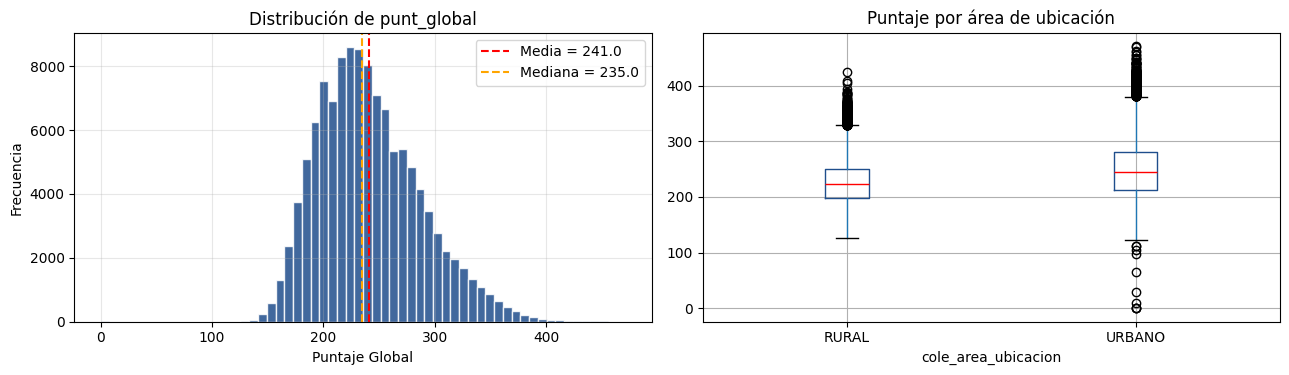

In [18]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_reg['punt_global'], bins=60, color='#1f4e8c', edgecolor='white', alpha=0.85)
axes[0].axvline(df_reg['punt_global'].mean(), color='red', linestyle='--',
                label=f"Media = {df_reg['punt_global'].mean():.1f}")
axes[0].axvline(df_reg['punt_global'].median(), color='orange', linestyle='--',
                label=f"Mediana = {df_reg['punt_global'].median():.1f}")
axes[0].set_xlabel('Puntaje Global'); axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de punt_global')
axes[0].legend(); axes[0].grid(alpha=0.3)

df_reg.boxplot(column='punt_global', by='cole_area_ubicacion', ax=axes[1],
               boxprops=dict(color='#1f4e8c'), medianprops=dict(color='red'))
axes[1].set_title('Puntaje por área de ubicación')
plt.suptitle('')
plt.tight_layout(); plt.show()

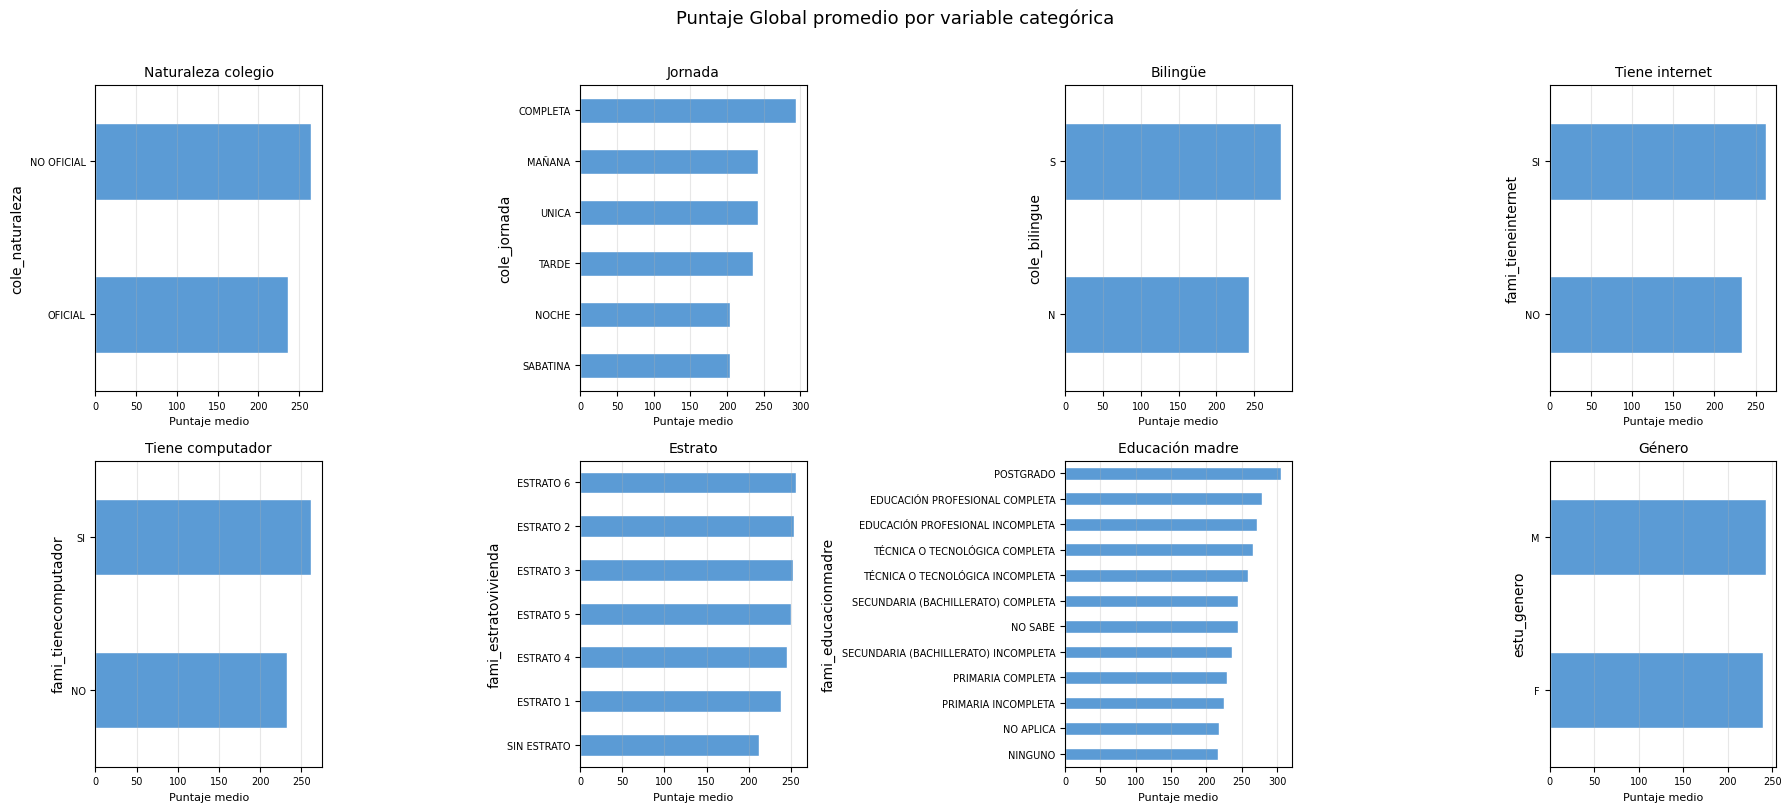

In [19]:
# Puntaje promedio por las variables categóricas más relevantes
vars_explorar = [
    ('cole_naturaleza',       'Naturaleza colegio'),
    ('cole_jornada',          'Jornada'),
    ('cole_bilingue',         'Bilingüe'),
    ('fami_tieneinternet',    'Tiene internet'),
    ('fami_tienecomputador',  'Tiene computador'),
    ('fami_estratovivienda',  'Estrato'),
    ('fami_educacionmadre',   'Educación madre'),
    ('estu_genero',           'Género'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, (col, titulo) in zip(axes, vars_explorar):
    media = df_reg.groupby(col)['punt_global'].mean().sort_values().dropna()
    media.plot(kind='barh', ax=ax, color='#5b9bd5', edgecolor='white')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Puntaje medio', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3, axis='x')

plt.suptitle('Puntaje Global promedio por variable categórica', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 3. Preprocesamiento

**Variables seleccionadas:** todas las disponibles antes de la prueba. Se excluyen `punt_*` (leakage), identificadores y fechas crudas.

**Estandarización:** obligatoria para Lasso (la penalización L1 opera en la misma escala) y para las redes neuronales (sensibles a la magnitud de los inputs). Se aplica `StandardScaler` a variables numéricas y ordinales.

In [20]:
# Calcular edad
df_reg['estu_fechanacimiento'] = pd.to_datetime(df_reg['estu_fechanacimiento'], errors='coerce')
df_reg['edad'] = (pd.to_datetime('2022-12-31') - df_reg['estu_fechanacimiento']).dt.days // 365

# Imputar nulos
df_reg['cole_bilingue'] = df_reg['cole_bilingue'].fillna('N')
df_reg['edad']          = df_reg['edad'].fillna(df_reg['edad'].median())
for col in df_reg.select_dtypes(include='object').columns:
    df_reg[col] = df_reg[col].fillna('NO INFORMA')

# Definición de features
cat_features = [
    'cole_area_ubicacion', 'cole_naturaleza', 'cole_jornada',
    'cole_calendario', 'cole_caracter', 'cole_bilingue', 'cole_genero',
    'estu_genero', 'fami_tieneinternet', 'fami_tienecomputador',
    'fami_tieneautomovil', 'fami_tienelavadora', 'cole_sede_principal'
]
ord_features = [
    'fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre',
    'fami_cuartoshogar', 'fami_personashogar'
]
num_features = ['edad']
all_features = cat_features + ord_features + num_features

X = df_reg[all_features].copy()
y = df_reg['punt_global'].copy()

print(f'Features: {len(all_features)}  (cat={len(cat_features)}, ord={len(ord_features)}, num={len(num_features)})')
print(f'Filas: {X.shape[0]:,}  |  Nulos restantes: {X.isnull().sum().sum()}')

Features: 19  (cat=13, ord=5, num=1)
Filas: 118,523  |  Nulos restantes: 0


In [21]:
# Split 70 / 15 / 15
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.176, random_state=42)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

# Preprocesador: OHE para categóricas + StandardScaler para numéricas y ordinales
# Se ajusta SOLO con X_train para evitar data leakage
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     cat_features + ord_features),
    ('num', StandardScaler(), num_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

print(f'Shape tras preprocesamiento: {X_train_p.shape}')

Train: 83,013  |  Val: 17,731  |  Test: 17,779
Shape tras preprocesamiento: (83013, 103)


## 4. Lasso — selección de variables

Lasso agrega una penalización L1 a la regresión lineal:

$$\min_{\beta} \left\{ \frac{1}{n}\|y - X\beta\|^2 + \alpha \sum_j |\beta_j| \right\}$$

La penalización L1 lleva coeficientes irrelevantes exactamente a **cero**, seleccionando automáticamente las variables con señal real.

> **Por qué estandarizar antes de Lasso:** la penalización `α|β_j|` trata igual a todas las variables solo si están en la misma escala. Sin estandarización, una variable con valores grandes tendría un coeficiente pequeño aunque sea importante, y sería penalizada injustamente.

Usamos `LassoCV` para encontrar el `α` óptimo con validación cruzada de 5 folds.

Alpha óptimo encontrado: 0.001791


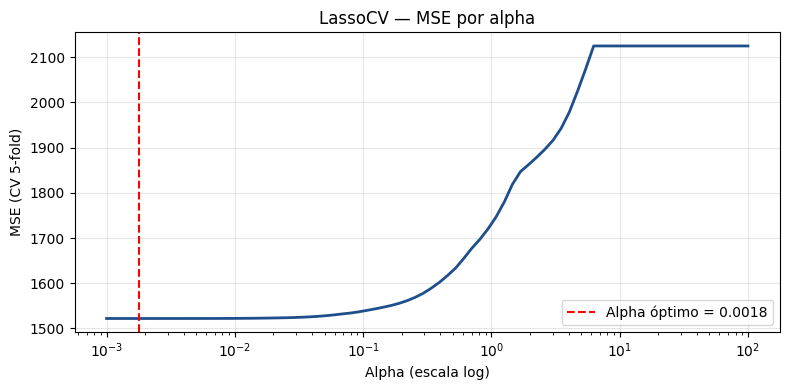

In [22]:
# LassoCV: busca el alpha óptimo en el rango dado
lasso_cv = LassoCV(
    alphas=np.logspace(-3, 2, 80),
    cv=5,
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)
lasso_cv.fit(X_train_p, y_train)

best_alpha = lasso_cv.alpha_
print(f'Alpha óptimo encontrado: {best_alpha:.6f}')

# Curva MSE vs alpha
mse_path = np.mean(lasso_cv.mse_path_, axis=1)
plt.figure(figsize=(8, 4))
plt.semilogx(lasso_cv.alphas_, mse_path, color='#1f4e8c', linewidth=2)
plt.axvline(best_alpha, color='red', linestyle='--',
            label=f'Alpha óptimo = {best_alpha:.4f}')
plt.xlabel('Alpha (escala log)'); plt.ylabel('MSE (CV 5-fold)')
plt.title('LassoCV — MSE por alpha')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Total features:      103
Seleccionadas (≠ 0): 89
Eliminadas (= 0):    14


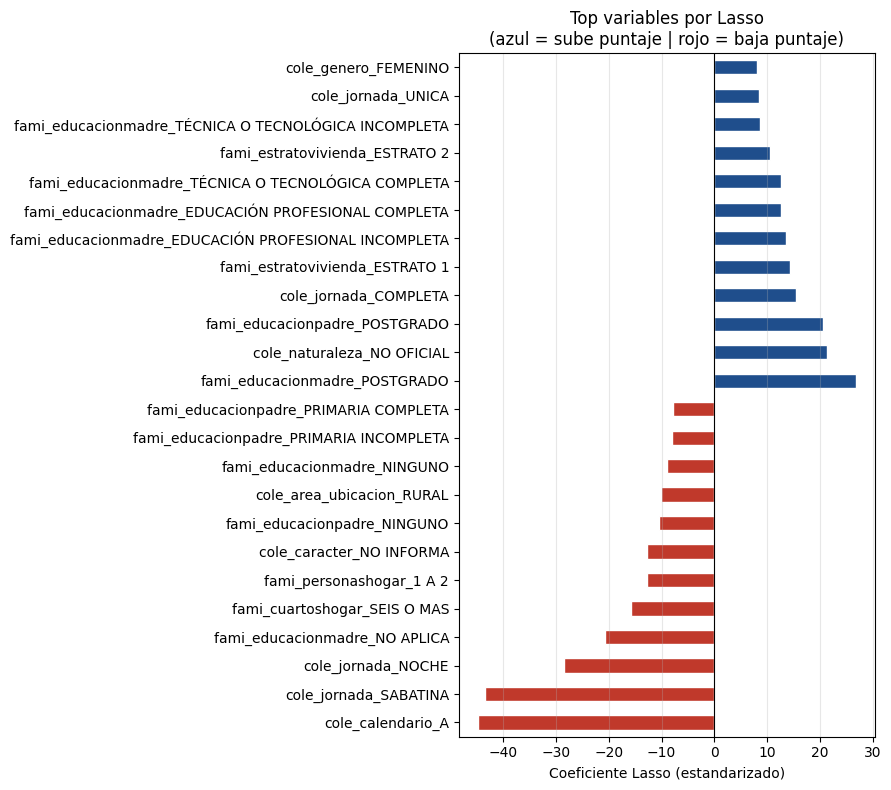

In [23]:
# Variables seleccionadas (coeficiente ≠ 0)
feature_names = preprocessor.get_feature_names_out()
coefs = pd.Series(lasso_cv.coef_, index=feature_names)

n_sel = (coefs != 0).sum()
n_zer = (coefs == 0).sum()
print(f'Total features:      {len(coefs)}')
print(f'Seleccionadas (≠ 0): {n_sel}')
print(f'Eliminadas (= 0):    {n_zer}')

# Top features por magnitud de coeficiente
top = pd.concat([
    coefs[coefs < 0].nsmallest(12),
    coefs[coefs > 0].nlargest(12)
])
top.index = (top.index
    .str.replace('cat__', '', regex=False)
    .str.replace('num__', '', regex=False))

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#c0392b' if v < 0 else '#1f4e8c' for v in top.values]
top.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente Lasso (estandarizado)')
ax.set_title('Top variables por Lasso\n(azul = sube puntaje | rojo = baja puntaje)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

In [24]:
# Aplicar máscara de selección a los tres splits
selected_mask = (coefs != 0).values

X_train_s = X_train_p[:, selected_mask]
X_val_s   = X_val_p[:, selected_mask]
X_test_s  = X_test_p[:, selected_mask]

print(f'Dimensión COMPLETA:   {X_train_p.shape[1]} features')
print(f'Dimensión REDUCIDA:   {X_train_s.shape[1]} features')

Dimensión COMPLETA:   103 features
Dimensión REDUCIDA:   89 features


## 5. Función de métricas

Las fórmulas de cada métrica (donde $n$ = número de observaciones, $p$ = número de features):

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 \qquad \text{RMSE} = \sqrt{\text{MSE}}$$

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}\lvert y_i - \hat{y}_i \rvert \qquad \text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\frac{\lvert y_i - \hat{y}_i \rvert}{y_i} \times 100$$

$$R^2 = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2} \qquad R^2_{\text{adj}} = 1 - (1-R^2)\frac{n-1}{n-p-1}$$

| Métrica | Interpretación |
|---|---|
| MSE | Error cuadrático medio — penaliza errores grandes |
| RMSE | Raíz del MSE — en unidades del puntaje, más fácil de leer |
| MAE | Error absoluto medio en puntos — robusto a outliers |
| MAPE | Error relativo en % — independiente de la escala del puntaje |
| R² | Proporción de varianza explicada (1 = predicción perfecta) |
| R² ajustado | R² penalizado por el número de features — evita sobreajuste aparente |
| Var. explicada | Similar a R² pero ignora sesgo sistemático constante |

In [25]:
def calcular_metricas(y_true, y_pred, n_features, label=''):
    n     = len(y_true)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((np.array(y_true) - y_pred) / np.array(y_true))) * 100
    r2    = r2_score(y_true, y_pred)
    r2adj = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    ev    = explained_variance_score(y_true, y_pred)

    if label:
        sep = '─' * 58
        print(f'\n{sep}')
        print(f'  {label}')
        print(f'{sep}')
        print(f'  MSE            : {mse:>10.4f}')
        print(f'  RMSE           : {rmse:>10.4f}  pts')
        print(f'  MAE            : {mae:>10.4f}  pts')
        print(f'  MAPE           : {mape:>10.2f} %')
        print(f'  R²             : {r2:>10.4f}')
        print(f'  R² ajustado    : {r2adj:>10.4f}')
        print(f'  Var. explicada : {ev:>10.4f}')

    return dict(MSE=mse, RMSE=rmse, MAE=mae, MAPE=mape,
                R2=r2, R2_adj=r2adj, EV=ev)


# ── Lasso como referencia lineal ─────────────────────────────────────────
y_val_lasso = lasso_cv.predict(X_val_p)
m_lasso = calcular_metricas(y_val, y_val_lasso, X_train_s.shape[1],
                            'Lasso — Validación (referencia lineal)')


──────────────────────────────────────────────────────────
  Lasso — Validación (referencia lineal)
──────────────────────────────────────────────────────────
  MSE            :  1494.9719
  RMSE           :    38.6649  pts
  MAE            :    30.8293  pts
  MAPE           :      13.17 %
  R²             :     0.2792
  R² ajustado    :     0.2756
  Var. explicada :     0.2793


## 6. Redes neuronales — comparación de arquitecturas

El experimento tiene **dos partes**:

**Parte A — NN con todas las features (referencia):** entrenamos una red neuronal con la arquitectura 128-64-32 usando el conjunto completo de features (antes de aplicar Lasso). Sirve para ver si la selección de variables realmente mejora el modelo.

**Parte B — NNs con features seleccionadas por Lasso:** con las variables que Lasso retuvo, entrenamos 6 arquitecturas distintas variando:
- Número de capas ocultas: 1, 2 y 3
- Número de neuronas: de 32 a 256
- Dropout: 0.0 a 0.4
- Learning rate: 1e-3 y 5e-4

Todas las redes usan activación **ReLU**, salida **lineal** (regresión), pérdida **MSE** y **EarlyStopping** sobre MAE en validación (paciencia 7 épocas).

In [26]:
def construir_red(input_dim, capas, dropout=0.0, lr=1e-3):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for n_neuronas in capas:
        model.add(layers.Dense(n_neuronas, activation='relu'))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1))   # salida lineal para regresión
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=[
            keras.metrics.MeanAbsoluteError(name='mae'),
            keras.metrics.RootMeanSquaredError(name='rmse'),
        ]
    )
    return model


resultados = []

# ════════════════════════════════════════════════════════════════════════
# PARTE A — NN con TODAS las features (sin selección Lasso)
# ════════════════════════════════════════════════════════════════════════
print('─' * 60)
print('  PARTE A — NN con TODAS las features (sin Lasso)')
print(f'  Dimensión de entrada: {X_train_p.shape[1]} features')
print('─' * 60)

with mlflow.start_run(run_name='NN-REF_todas_features'):
    mlflow.log_params({
        'capas':      '128-64-32',
        'dropout':    0.3,
        'lr':         1e-3,
        'n_feats':    X_train_p.shape[1],
        'seleccion':  'ninguna (todas)',
    })

    model_ref = construir_red(X_train_p.shape[1],
                              capas=[128, 64, 32],
                              dropout=0.3, lr=1e-3)
    hist_ref = model_ref.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=100, batch_size=256,
        callbacks=[keras.callbacks.EarlyStopping(
            monitor='val_mae', patience=7, restore_best_weights=True)],
        verbose=0
    )

    y_pred_ref = model_ref.predict(X_val_p, verbose=0).ravel()
    m_ref = calcular_metricas(y_val, y_pred_ref, X_train_p.shape[1])

    for k, v in m_ref.items():
        mlflow.log_metric(f'val_{k.lower()}', v)

    resultados.append({
        'Modelo':     'NN-REF (todas)',
        'Capas':      '128-64-32',
        'Dropout':    0.3,
        'LR':         1e-3,
        'Features':   f'{X_train_p.shape[1]} (todas)',
        'Épocas':     len(hist_ref.history['loss']),
        **m_ref
    })
    print(f"NN-REF  capas=128-64-32  "
          f"RMSE={m_ref['RMSE']:.3f}  MAE={m_ref['MAE']:.3f}  "
          f"R²={m_ref['R2']:.4f}  MAPE={m_ref['MAPE']:.1f}%  "
          f"épocas={len(hist_ref.history['loss'])}")

# ════════════════════════════════════════════════════════════════════════
# PARTE B — NNs con features SELECCIONADAS por Lasso
# ════════════════════════════════════════════════════════════════════════
print(f'\n{"─"*60}')
print(f'  PARTE B — NNs con features seleccionadas por Lasso')
print(f'  Dimensión de entrada: {X_train_s.shape[1]} features')
print(f'{"─"*60}')

experimentos = [
    {'id': 'NN-1',  'capas': [64],             'dropout': 0.0, 'lr': 1e-3},
    {'id': 'NN-2',  'capas': [128, 64],        'dropout': 0.2, 'lr': 1e-3},
    {'id': 'NN-3',  'capas': [64, 32],         'dropout': 0.3, 'lr': 1e-3},
    {'id': 'NN-4',  'capas': [128, 64, 32],    'dropout': 0.3, 'lr': 1e-3},
    {'id': 'NN-5',  'capas': [256, 128, 64],   'dropout': 0.4, 'lr': 1e-3},
    {'id': 'NN-6',  'capas': [128, 64, 32],    'dropout': 0.3, 'lr': 5e-4},
]

for exp in experimentos:
    with mlflow.start_run(run_name=exp['id']):
        mlflow.log_params({
            'capas':     '-'.join(map(str, exp['capas'])),
            'dropout':   exp['dropout'],
            'lr':        exp['lr'],
            'n_feats':   X_train_s.shape[1],
            'seleccion': 'Lasso',
        })

        model = construir_red(X_train_s.shape[1],
                              capas=exp['capas'],
                              dropout=exp['dropout'],
                              lr=exp['lr'])

        hist = model.fit(
            X_train_s, y_train,
            validation_data=(X_val_s, y_val),
            epochs=100, batch_size=256,
            callbacks=[keras.callbacks.EarlyStopping(
                monitor='val_mae', patience=7, restore_best_weights=True)],
            verbose=0
        )

        y_pred = model.predict(X_val_s, verbose=0).ravel()
        m = calcular_metricas(y_val, y_pred, X_train_s.shape[1])

        for k, v in m.items():
            mlflow.log_metric(f'val_{k.lower()}', v)
        mlflow.log_metric('epocas', len(hist.history['loss']))

        resultados.append({
            'Modelo':    exp['id'],
            'Capas':     '-'.join(map(str, exp['capas'])),
            'Dropout':   exp['dropout'],
            'LR':        exp['lr'],
            'Features':  f'{X_train_s.shape[1]} (Lasso)',
            'Épocas':    len(hist.history['loss']),
            **m
        })

        print(f"{exp['id']:<6}  capas={'-'.join(map(str,exp['capas'])):<12}  "
              f"RMSE={m['RMSE']:.3f}  MAE={m['MAE']:.3f}  R²={m['R2']:.4f}  "
              f"MAPE={m['MAPE']:.1f}%  épocas={len(hist.history['loss'])}")

────────────────────────────────────────────────────────────
  PARTE A — NN con TODAS las features (sin Lasso)
  Dimensión de entrada: 103 features
────────────────────────────────────────────────────────────
NN-REF  capas=128-64-32  RMSE=38.137  MAE=30.134  R²=0.2988  MAPE=12.6%  épocas=35

────────────────────────────────────────────────────────────
  PARTE B — NNs con features seleccionadas por Lasso
  Dimensión de entrada: 89 features
────────────────────────────────────────────────────────────
NN-1    capas=64            RMSE=37.558  MAE=29.884  R²=0.3199  MAPE=12.8%  épocas=100
NN-2    capas=128-64        RMSE=37.841  MAE=30.012  R²=0.3096  MAPE=12.7%  épocas=49
NN-3    capas=64-32         RMSE=38.026  MAE=30.133  R²=0.3029  MAPE=12.7%  épocas=100
NN-4    capas=128-64-32     RMSE=38.319  MAE=30.256  R²=0.2921  MAPE=12.6%  épocas=43
NN-5    capas=256-128-64    RMSE=37.998  MAE=30.087  R²=0.3039  MAPE=12.7%  épocas=26
NN-6    capas=128-64-32     RMSE=38.362  MAE=30.332  R²=0.2905  

## 7. Tabla comparativa de métricas

In [27]:
df_res = pd.DataFrame(resultados)

# Agregar filas de Lasso y NN-REF al inicio
fila_lasso = {
    'Modelo': 'Lasso', 'Capas': '(lineal)', 'Dropout': '—', 'LR': '—',
    'Features': f'{X_train_p.shape[1]} (todas)', 'Épocas': '—', **m_lasso
}
df_res = pd.concat([pd.DataFrame([fila_lasso]), df_res], ignore_index=True)

cols = ['Modelo', 'Features', 'Capas', 'MSE', 'RMSE', 'MAE', 'MAPE', 'R2', 'R2_adj', 'EV']

fmt = lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)

print()
print('=' * 100)
print('  COMPARACIÓN COMPLETA — Conjunto de Validación')
print('=' * 100)
print(f'  {"Modelo":<18} {"Features":<22} {"Capas":<14} '
      f'{"MSE":>8} {"RMSE":>7} {"MAE":>7} {"MAPE":>7} {"R²":>7} {"R²adj":>7} {"EV":>7}')
print('─' * 100)

for _, row in df_res.iterrows():
    # Separador visual entre Lasso/NN-REF y las NNs con Lasso
    if row['Modelo'] == 'NN-1':
        print('  ' + '·' * 96)
        print(f'  {"▼ NNs con features seleccionadas por Lasso":}')
        print('  ' + '·' * 96)

    vals = [row.get(c, '—') for c in ['MSE','RMSE','MAE','MAPE','R2','R2_adj','EV']]
    vals_str = '  '.join(f'{fmt(v):>7}' for v in vals)
    print(f"  {row['Modelo']:<18} {row['Features']:<22} {row['Capas']:<14}  {vals_str}")

print('=' * 100)

# Mejor modelo por RMSE entre las NNs con Lasso
nn_lasso = df_res[df_res['Features'].str.contains('Lasso')]
mejor_idx = nn_lasso['RMSE'].astype(float).idxmin()
mejor = df_res.loc[mejor_idx]
ref_rmse = float(df_res[df_res['Modelo'] == 'NN-REF (todas)']['RMSE'].values[0])

print(f"\nMejor NN con Lasso: {mejor['Modelo']}  (RMSE={float(mejor['RMSE']):.4f}  R²={float(mejor['R2']):.4f})")
print(f"NN-REF (todas):                     RMSE={ref_rmse:.4f}")
mejora = ref_rmse - float(mejor['RMSE'])
signo  = 'mejoró' if mejora > 0 else 'empeoró'
print(f"Diferencia:  {abs(mejora):.4f} pts  → Lasso {signo} el RMSE en {abs(mejora):.2f} puntos")


  COMPARACIÓN COMPLETA — Conjunto de Validación
  Modelo             Features               Capas               MSE    RMSE     MAE    MAPE      R²   R²adj      EV
────────────────────────────────────────────────────────────────────────────────────────────────────
  Lasso              103 (todas)            (lineal)        1494.9719  38.6649  30.8293  13.1673   0.2792   0.2756   0.2793
  NN-REF (todas)     103 (todas)            128-64-32       1454.4636  38.1374  30.1343  12.6111   0.2988   0.2947   0.3082
  ································································································
  ▼ NNs con features seleccionadas por Lasso
  ································································································
  NN-1               89 (Lasso)             64              1410.6358  37.5584  29.8838  12.7663   0.3199   0.3165   0.3199
  NN-2               89 (Lasso)             128-64          1431.9098  37.8406  30.0120  12.6821   0.3096   0.3062   0.

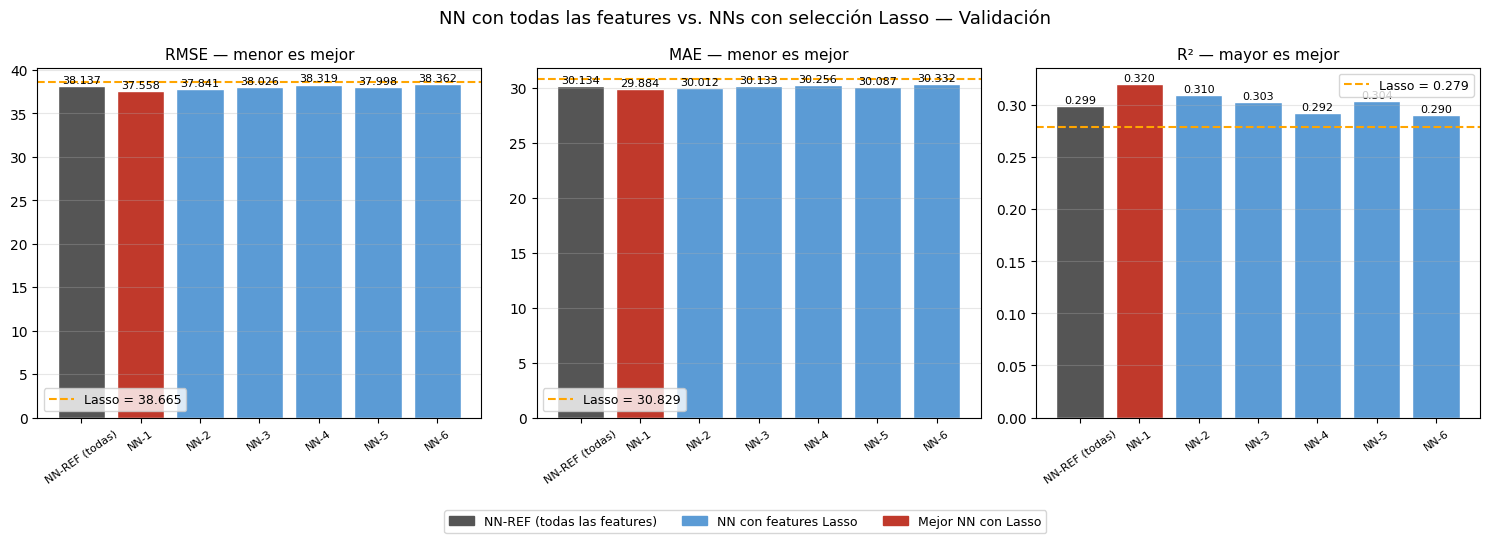

In [28]:
# ── Gráfica comparativa ──────────────────────────────────────────────────
# Orden: Lasso, NN-REF, luego NNs con Lasso
df_plot = df_res[df_res['Modelo'] != 'Lasso'].copy()
mejor_id = mejor['Modelo']

# Colores: rojo = mejor NN con Lasso, gris oscuro = NN-REF (todas), azul = resto
colores = []
for m_id in df_plot['Modelo']:
    if m_id == mejor_id:
        colores.append('#c0392b')       # mejor
    elif m_id == 'NN-REF (todas)':
        colores.append('#555555')       # referencia
    else:
        colores.append('#5b9bd5')       # resto

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metrica, titulo in zip(
        axes,
        ['RMSE', 'MAE', 'R2'],
        ['RMSE — menor es mejor', 'MAE — menor es mejor', 'R² — mayor es mejor']):

    ax.bar(df_plot['Modelo'], df_plot[metrica].astype(float),
           color=colores, edgecolor='white')

    # Lasso como línea de referencia
    ref_val = float(df_res[df_res['Modelo'] == 'Lasso'][metrica].values[0])
    ax.axhline(ref_val, color='orange', linestyle='--', linewidth=1.5,
               label=f'Lasso = {ref_val:.3f}')

    ax.set_title(titulo, fontsize=11)
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

    for bar, val in zip(ax.patches, df_plot[metrica].astype(float)):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003 * bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Leyenda de colores
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#555555', label='NN-REF (todas las features)'),
    Patch(color='#5b9bd5', label='NN con features Lasso'),
    Patch(color='#c0392b', label='Mejor NN con Lasso'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('NN con todas las features vs. NNs con selección Lasso — Validación',
             fontsize=13)
plt.tight_layout(); plt.show()

## 8. Evaluación final del mejor modelo en test

Re-entrenamos el mejor modelo con **train + val** y lo evaluamos en **test** (primera y única vez).

In [29]:
# Configuración del mejor modelo
mejor_exp = next(e for e in experimentos if e['id'] == mejor_id)

# Re-entrenar con train + val
X_full_s = np.vstack([X_train_s, X_val_s])
y_full   = pd.concat([y_train, y_val])

with mlflow.start_run(run_name=f"{mejor_id}_FINAL_TEST"):
    mlflow.log_params({
        'capas':  '-'.join(map(str, mejor_exp['capas'])),
        'dropout': mejor_exp['dropout'],
        'lr':     mejor_exp['lr'],
        'datos':  'train+val',
    })

    modelo_final = construir_red(
        X_full_s.shape[1],
        capas=mejor_exp['capas'],
        dropout=mejor_exp['dropout'],
        lr=mejor_exp['lr']
    )
    modelo_final.fit(X_full_s, y_full, epochs=50, batch_size=256, verbose=0)

    y_test_pred = modelo_final.predict(X_test_s, verbose=0).ravel()
    m_test = calcular_metricas(
        y_test, y_test_pred, X_test_s.shape[1],
        f'{mejor_id} — EVALUACIÓN FINAL EN TEST'
    )

    for k, v in m_test.items():
        mlflow.log_metric(f'test_{k.lower()}', v)


──────────────────────────────────────────────────────────
  NN-1 — EVALUACIÓN FINAL EN TEST
──────────────────────────────────────────────────────────
  MSE            :  1450.6900
  RMSE           :    38.0879  pts
  MAE            :    30.3517  pts
  MAPE           :      12.93 %
  R²             :     0.3153
  R² ajustado    :     0.3118
  Var. explicada :     0.3153


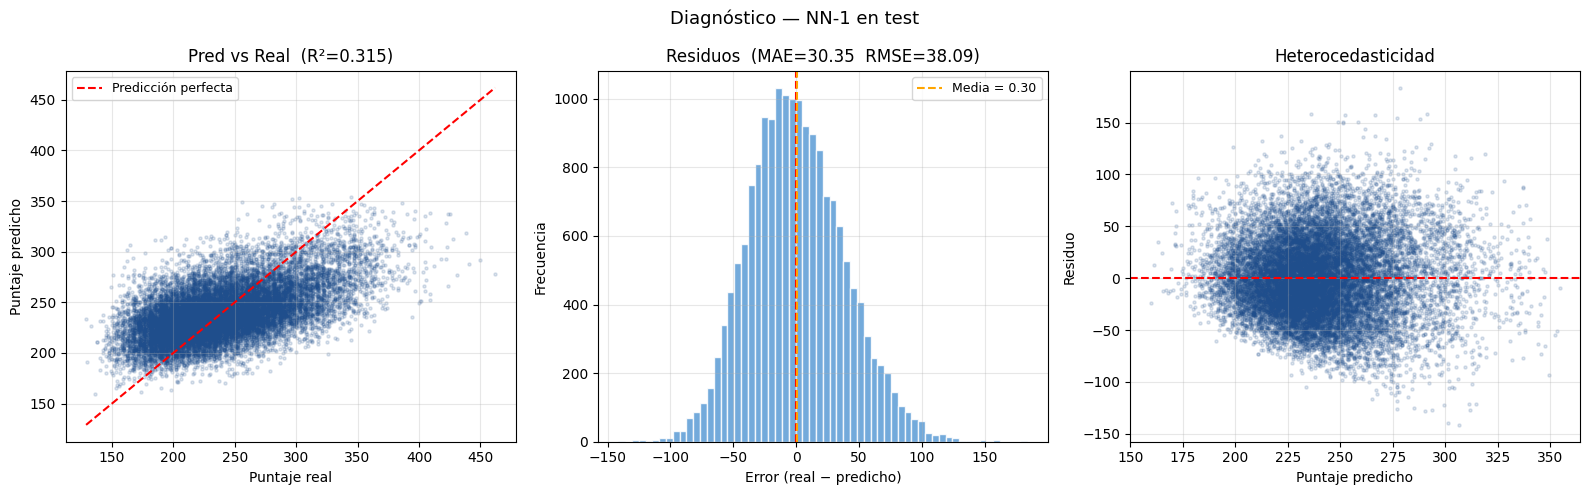


Interpretación del error:
  El modelo se equivoca en promedio 30.4 puntos (MAE)
  Error relativo medio: 12.9% (MAPE)
  Explica el 31.5% de la varianza del puntaje (R²)


In [30]:
# Gráficas diagnóstico
residuos = y_test.values - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pred vs real
ax = axes[0]
ax.scatter(y_test, y_test_pred, alpha=0.15, s=5, color='#1f4e8c')
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Puntaje real'); ax.set_ylabel('Puntaje predicho')
ax.set_title(f'Pred vs Real  (R²={m_test["R2"]:.3f})')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Distribución de residuos
ax = axes[1]
ax.hist(residuos, bins=60, color='#5b9bd5', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(residuos.mean(), color='orange', linestyle='--',
           label=f'Media = {residuos.mean():.2f}')
ax.set_xlabel('Error (real − predicho)'); ax.set_ylabel('Frecuencia')
ax.set_title(f'Residuos  (MAE={m_test["MAE"]:.2f}  RMSE={m_test["RMSE"]:.2f})')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Residuos vs predicho
ax = axes[2]
ax.scatter(y_test_pred, residuos, alpha=0.15, s=5, color='#1f4e8c')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Puntaje predicho'); ax.set_ylabel('Residuo')
ax.set_title('Heterocedasticidad')
ax.grid(alpha=0.3)

plt.suptitle(f'Diagnóstico — {mejor_id} en test', fontsize=13)
plt.tight_layout(); plt.show()

print(f'\nInterpretación del error:')
print(f'  El modelo se equivoca en promedio {m_test["MAE"]:.1f} puntos (MAE)')
print(f'  Error relativo medio: {m_test["MAPE"]:.1f}% (MAPE)')
print(f'  Explica el {m_test["R2"]*100:.1f}% de la varianza del puntaje (R²)')